# Optimisation results analysis

This notebook extracts the core Python workflow from the Quarto document into a Jupyter notebook.

It is set up to:

1. load optimisation results for one or two specific runs,
2. plot selection frequency for each run and compare maps side by side,
3. run the Jaccard similarity analysis in one of two modes,
   [between multiple seeds], or
   [within the Pareto optimal solutions of a selected run],
4. plot Pareto fronts side by side,
5. plot parallel coordinates side by side.

Update the paths and analysis settings in the configuration cell before executing the notebook.


In [12]:
from pathlib import Path
import os
import sys
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional, but used by the original workflow
try:
    from pymoo.indicators.hv import HV
    from pymoo.util.callback import Callback
except Exception:
    HV = None

    class Callback:
        pass

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------

# Set this to the root of the optimisation project, the folder that contains
# visualisations.py, analyze_spatial_agreement.py, patch_approach.py, etc.
PROJECT_ROOT = Path(".")

# Specific runs to load for plotting and side-by-side comparison
RUN_PKL_A = PROJECT_ROOT / "patch_tests_1903_2/forest_2_100/results_forest_1903_1.pkl"
RUN_PKL_B = PROJECT_ROOT / "patch_tests_1903/forest_2_100/results_forest_1903_1.pkl"

# Labels used in plot titles and output file names
RUN_LABEL_A = "Run A"
RUN_LABEL_B = "Run B"

# Set RUN_PKL_B = None to analyse only one run
RUN_CONFIGS = [
    {"label": RUN_LABEL_A, "pkl": RUN_PKL_A},
    {"label": RUN_LABEL_B, "pkl": RUN_PKL_B},
]

# Ecosystem label, used in titles and in the Jaccard analysis
ECOSYSTEM = "forest"

# Set to True if run files contain patch based results that need conversion
USE_PATCH_APPROACH = False

# Directory to save figures and tables
OUTPUT_DIR = PROJECT_ROOT / "notebook_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Jaccard similarity analysis mode
# -----------------------------------------------------------------------------

# Choose one:
#   "between_seeds"      -> compare solutions across repeated runs with different seeds
#   "within_run_pareto"  -> compare Pareto optimal solutions within the loaded run
JACCARD_MODE = "within_run_pareto"

# Choose which loaded run to use for Jaccard when two runs are configured
JACCARD_RUN_LABEL = RUN_LABEL_A

# -----------------------------------------------------------------------------
# Between-seeds Jaccard settings
# -----------------------------------------------------------------------------

# These reproduce the Quarto workflow for spatial agreement analysis
FILE_DATE = "1703"
FILE_START = 11
FILE_END = 20
K_NEIGHBORS = 5

# -----------------------------------------------------------------------------
# Within-run Pareto Jaccard settings
# -----------------------------------------------------------------------------

# If True, use only non dominated solutions from the loaded run.
# If False, use every solution in the loaded run.
USE_ONLY_PARETO_SOLUTIONS = True

# Add project root to Python path
project_root_str = str(PROJECT_ROOT.resolve())
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

print(f"Project root:  {PROJECT_ROOT.resolve()}")
print(f"Output dir:    {OUTPUT_DIR.resolve()}")
print(f"Jaccard mode:  {JACCARD_MODE}")
print(f"Jaccard run:   {JACCARD_RUN_LABEL}")
for cfg in RUN_CONFIGS:
    if cfg["pkl"] is not None:
        print(f"{cfg['label']}: {cfg['pkl']}")


Project root:  C:\Users\inicholson\Documents\rest_prio
Output dir:    C:\Users\inicholson\Documents\rest_prio\notebook_outputs
Jaccard mode:  within_run_pareto
Jaccard run:   Run A
Run A: patch_tests_1903_2\forest_2_100\results_forest_1903_1.pkl
Run B: patch_tests_1903\forest_2_100\results_forest_1903_1.pkl


In [13]:

# -----------------------------------------------------------------------------
# Safe pickle loading, adapted from the Quarto document
# -----------------------------------------------------------------------------

class HVCallback(Callback):
    def __init__(self, ref_point=None):
        super().__init__()
        self.ref_point = ref_point
        self.hv = HV(ref_point=ref_point) if HV is not None and ref_point is not None else None
        self.history = []

    def notify(self, algorithm):
        if self.hv is not None:
            hv_value = self.hv.do(algorithm.pop.get("F"))
            self.history.append(hv_value)


class SafeUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if name == "HVCallback":
            return HVCallback
        try:
            return super().find_class(module, name)
        except (ImportError, AttributeError) as e:
            warnings.warn(f"Could not import {module}.{name}, using dummy class: {e}")

            class DummyClass:
                def __init__(self, *args, **kwargs):
                    pass

            return DummyClass


def safe_pickle_load(file_path):
    file_path = Path(file_path)
    with open(file_path, "rb") as f:
        return SafeUnpickler(f).load()


In [14]:
# -----------------------------------------------------------------------------
# Imports from the optimisation project
# -----------------------------------------------------------------------------

import visualisations
from visualisations import (
    create_selection_frequency_map,
    plot_pareto_front,
    plot_parallel_coordinates,
)

try:
    from analyze_spatial_agreement import analyze_spatial_agreement
except Exception:
    analyze_spatial_agreement = None

try:
    from patch_approach import convert_patch_results_to_pixel_decisions
except Exception:
    convert_patch_results_to_pixel_decisions = None

# Patch visualisations.load_results so it also uses the safe unpickler
original_load_results = visualisations.load_results

def patched_load_results(pkl_path, scenario_id=None):
    with open(pkl_path, "rb") as f:
        raw_results = SafeUnpickler(f).load()

    if isinstance(raw_results, dict) and "scenarios" in raw_results:
        if scenario_id == "all":
            all_results = []
            for sid in sorted(raw_results["scenarios"].keys()):
                scenario_results = raw_results["scenarios"][sid].copy()
                scenario_results["multi_scenario_info"] = {
                    "total_scenarios": raw_results["n_scenarios_total"],
                    "scenarios_run": raw_results["n_scenarios_run"],
                    "current_scenario_id": sid,
                    "all_scenario_ids": list(raw_results["scenarios"].keys()),
                }
                all_results.append(scenario_results)
            return all_results
        else:
            if scenario_id is None:
                scenario_id = 0
            if scenario_id not in raw_results["scenarios"]:
                available = list(raw_results["scenarios"].keys())
                raise ValueError(f"Scenario {scenario_id} not found. Available scenarios: {available}")
            results = raw_results["scenarios"][scenario_id].copy()
            results["multi_scenario_info"] = {
                "total_scenarios": raw_results["n_scenarios_total"],
                "scenarios_run": raw_results["n_scenarios_run"],
                "current_scenario_id": scenario_id,
                "all_scenario_ids": list(raw_results["scenarios"].keys()),
            }
            return results

    return raw_results

visualisations.load_results = patched_load_results

print("Project imports loaded.")
if analyze_spatial_agreement is None:
    print("Note: analyze_spatial_agreement could not be imported.")


Project imports loaded.


In [15]:

# -----------------------------------------------------------------------------
# Load selected run(s) and convert patch decisions if needed
# -----------------------------------------------------------------------------

loaded_runs = []

for cfg in RUN_CONFIGS:
    run_label = cfg["label"]
    run_pkl = cfg["pkl"]

    if run_pkl is None:
        continue
    if not Path(run_pkl).exists():
        print(f"Skipping {run_label}: file not found -> {run_pkl}")
        continue

    one_results = safe_pickle_load(run_pkl)
    run_for_plotting = Path(run_pkl)

    print(f"\n=== {run_label} ===")
    if isinstance(one_results, dict):
        print("Top level result keys:")
        print(sorted(one_results.keys()))

        for key in ["decisions", "X", "decisions_pixels", "decisions_patches"]:
            if key in one_results and hasattr(one_results[key], "shape"):
                print(f"{key}: {one_results[key].shape}")

        if "patch_mappings" in one_results:
            print("Patch mappings detected.")
            if USE_PATCH_APPROACH:
                if convert_patch_results_to_pixel_decisions is None:
                    raise ImportError("patch_approach.convert_patch_results_to_pixel_decisions is not available.")
                one_results = convert_patch_results_to_pixel_decisions(one_results, one_results["patch_mappings"])
                run_for_plotting = OUTPUT_DIR / f"{Path(run_pkl).stem}_pixels.pkl"
                with open(run_for_plotting, "wb") as f:
                    pickle.dump(one_results, f)
                print(f"Converted patch decisions saved to: {run_for_plotting}")
    else:
        print(f"Loaded object type: {type(one_results)}")
        if hasattr(one_results, "X"):
            print(f"X shape: {one_results.X.shape}")

    print(f"Run used for plotting: {run_for_plotting}")
    loaded_runs.append({
        "label": run_label,
        "input_path": Path(run_pkl),
        "plot_path": Path(run_for_plotting),
        "results": one_results,
    })

if len(loaded_runs) == 0:
    raise ValueError("No valid run files were loaded. Check RUN_PKL_A / RUN_PKL_B in the configuration cell.")

# Keep backward-compatible names for downstream cells.
# "results" defaults to the first loaded run.
results = loaded_runs[0]["results"]
run_for_plotting = loaded_runs[0]["plot_path"]

matching_jaccard_runs = [run for run in loaded_runs if run["label"] == JACCARD_RUN_LABEL]
if len(matching_jaccard_runs) == 0:
    available_labels = [run["label"] for run in loaded_runs]
    raise ValueError(
        f"JACCARD_RUN_LABEL '{JACCARD_RUN_LABEL}' was not loaded. Available labels: {available_labels}"
    )

jaccard_run = matching_jaccard_runs[0]
results_for_jaccard = jaccard_run["results"]
print(f"\nJaccard analysis will use: {jaccard_run['label']}")



=== Run A ===
Top level result keys:
['algorithm_info', 'decisions', 'full_population', 'hv_callback', 'initial_conditions', 'n_solutions', 'objective_names', 'objectives', 'patch_mappings', 'problem_info', 'scenario_params']
decisions: (50, 105847)
Patch mappings detected.
Run used for plotting: patch_tests_1903_2\forest_2_100\results_forest_1903_1.pkl

=== Run B ===
Top level result keys:
['algorithm_info', 'decisions', 'full_population', 'hv_callback', 'initial_conditions', 'n_solutions', 'objective_names', 'objectives', 'patch_mappings', 'problem_info', 'scenario_params']
decisions: (20, 105847)
Patch mappings detected.
Run used for plotting: patch_tests_1903\forest_2_100\results_forest_1903_1.pkl

Jaccard analysis will use: Run A


In [16]:
# -----------------------------------------------------------------------------
# Helper functions for robust Jaccard analysis
# -----------------------------------------------------------------------------

from itertools import combinations

try:
    from scipy.spatial.distance import cdist
except Exception:
    cdist = None


def extract_array_from_results(results_obj, candidates):
    if isinstance(results_obj, dict):
        for key in candidates:
            if key in results_obj and results_obj[key] is not None and np.size(results_obj[key]) > 0:
                return np.asarray(results_obj[key]), key
    else:
        for key in candidates:
            if hasattr(results_obj, key):
                value = getattr(results_obj, key)
                if value is not None and np.size(value) > 0:
                    return np.asarray(value), key
    return None, None


def extract_X_F(results_obj):
    X, x_key = extract_array_from_results(results_obj, ["X", "decisions_pixels", "decisions", "decisions_patches"])
    F, f_key = extract_array_from_results(results_obj, ["F", "objectives"])
    return X, F, x_key, f_key


def get_non_dominated_mask(F):
    F = np.asarray(F)
    n = F.shape[0]
    is_non_dominated = np.ones(n, dtype=bool)

    for i in range(n):
        if not is_non_dominated[i]:
            continue
        dominates_i = np.all(F <= F[i], axis=1) & np.any(F < F[i], axis=1)
        is_non_dominated[dominates_i] = False
    return is_non_dominated


def jaccard_similarity_binary(x1, x2):
    x1 = np.asarray(x1).astype(bool)
    x2 = np.asarray(x2).astype(bool)
    union = np.logical_or(x1, x2).sum()
    if union == 0:
        return 0.0
    intersection = np.logical_and(x1, x2).sum()
    return float(intersection / union)


def pairwise_jaccard_similarity_matrix(X_binary):
    X_binary = np.asarray(X_binary).astype(bool)
    n = X_binary.shape[0]
    out = np.eye(n, dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            s = jaccard_similarity_binary(X_binary[i], X_binary[j])
            out[i, j] = s
            out[j, i] = s
    return out


def analyse_within_run_jaccard(results_obj, use_only_pareto=True):
    X, F, x_key, f_key = extract_X_F(results_obj)
    if X is None:
        raise ValueError("Could not extract a decision matrix from the loaded run.")
    if F is None:
        raise ValueError("Could not extract an objective matrix from the loaded run.")

    if X.shape[0] != F.shape[0]:
        raise ValueError(f"X and F row counts do not match: X {X.shape}, F {F.shape}")

    selected_mask = np.ones(X.shape[0], dtype=bool)
    if use_only_pareto:
        selected_mask = get_non_dominated_mask(F)

    X_sel = X[selected_mask]
    F_sel = F[selected_mask]

    X_binary = np.asarray(X_sel).astype(int)

    jaccard_matrix = pairwise_jaccard_similarity_matrix(X_binary)

    if cdist is None:
        obj_dist_matrix = np.full((F_sel.shape[0], F_sel.shape[0]), np.nan)
    else:
        obj_dist_matrix = cdist(F_sel, F_sel, metric="euclidean")

    pair_rows = []
    for i, j in combinations(range(X_binary.shape[0]), 2):
        pair_rows.append({
            "solution_i": i,
            "solution_j": j,
            "jaccard_similarity": float(jaccard_matrix[i, j]),
            "objective_distance": float(obj_dist_matrix[i, j]) if cdist is not None else np.nan,
        })

    pair_df = pd.DataFrame(pair_rows)

    summary_rows = []
    for i in range(X_binary.shape[0]):
        mask_i = (pair_df["solution_i"] == i) | (pair_df["solution_j"] == i)
        one_df = pair_df.loc[mask_i]
        if len(one_df) == 0:
            continue
        summary_rows.append({
            "solution_idx": i,
            "mean_jaccard": float(one_df["jaccard_similarity"].mean()),
            "std_jaccard": float(one_df["jaccard_similarity"].std(ddof=0)),
            "min_jaccard": float(one_df["jaccard_similarity"].min()),
            "max_jaccard": float(one_df["jaccard_similarity"].max()),
            "mean_obj_distance": float(one_df["objective_distance"].mean()) if "objective_distance" in one_df else np.nan,
        })

    summary_df = pd.DataFrame(summary_rows)

    metadata = {
        "decision_source": x_key,
        "objective_source": f_key,
        "n_total_solutions": int(X.shape[0]),
        "n_selected_solutions": int(X_sel.shape[0]),
        "used_only_pareto": bool(use_only_pareto),
    }

    return {
        "X_selected": X_sel,
        "F_selected": F_sel,
        "X_binary": X_binary,
        "jaccard_matrix": jaccard_matrix,
        "pair_df": pair_df,
        "summary_df": summary_df,
        "metadata": metadata,
    }


## Selection frequency comparison

Loaded 50 Pareto-optimal solutions
Raster shape: (1131, 1215)
Eligible pixels: 189333
Decision vector shape: (50, 263835)
Calculating combined restoration + conversion frequency for separate pixel sets
Selection frequency range: 0.0% - 100.0%
Eligible pixels never selected: 224475 (85.1%)
✓ Selection frequency map saved to: notebook_outputs\selection_frequency_forest_run_a.png
Loaded 20 Pareto-optimal solutions
Raster shape: (1131, 1215)
Eligible pixels: 189333
Decision vector shape: (20, 263835)
Calculating combined restoration + conversion frequency for separate pixel sets
Selection frequency range: 0.0% - 100.0%
Eligible pixels never selected: 224552 (85.1%)
✓ Selection frequency map saved to: notebook_outputs\selection_frequency_forest_run_b.png

Selection-frequency spatial autocorrelation (Run A)
Saved map: notebook_outputs\selection_frequency_forest_run_a.png
Eligible pixels used: 263830
Selected at least once: 39355
Moran's I (queen contiguity): 0.5067
Expected I under spatial r

C:\Users\inicholson\AppData\Local\Temp\ipykernel_4564\3744761537.py:168: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("YlOrRd")


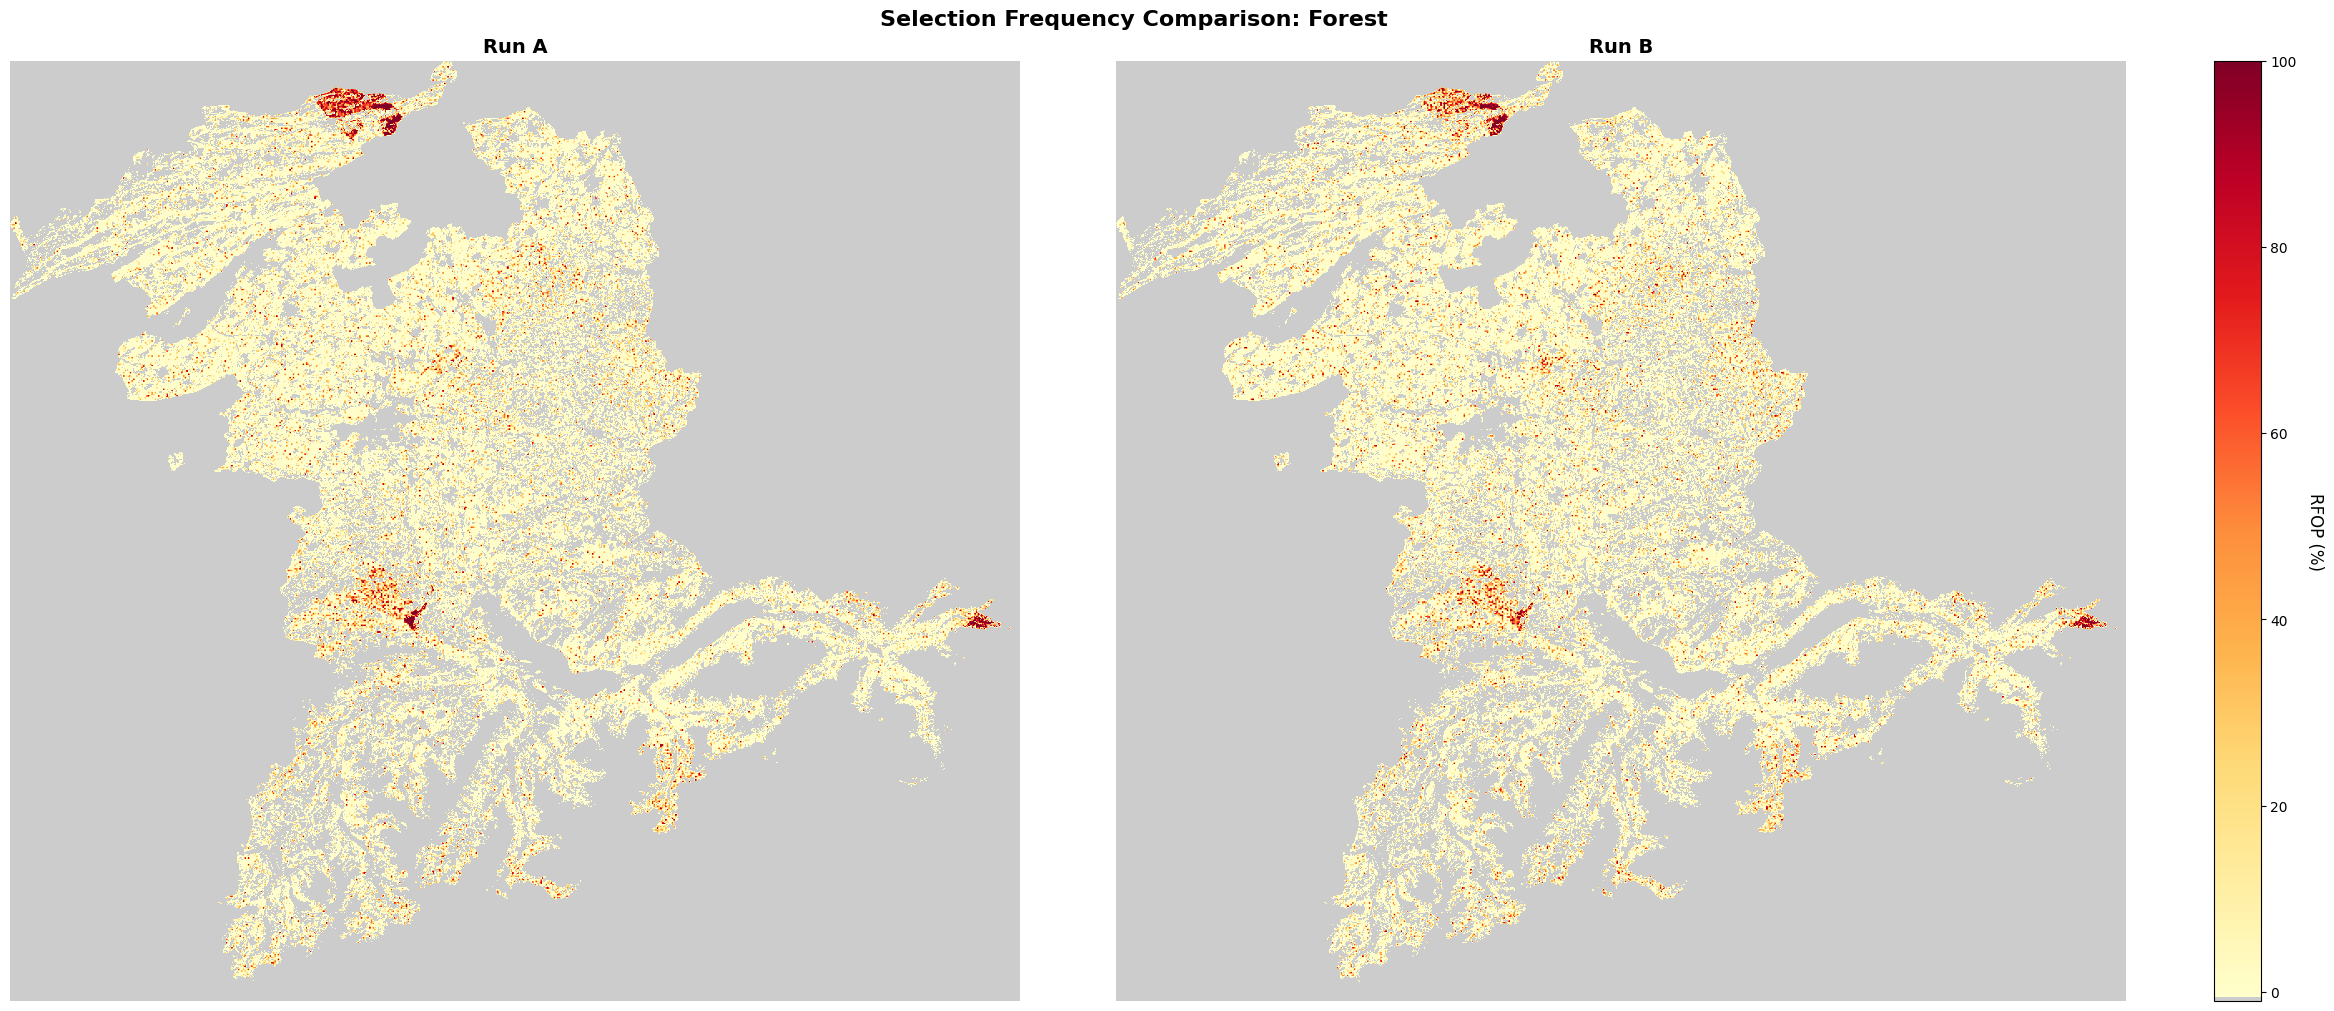

In [17]:
from contextlib import contextmanager
from matplotlib.colors import ListedColormap

@contextmanager
def _suppress_matplotlib_show():
    original_show = plt.show
    try:
        plt.show = lambda *args, **kwargs: None
        yield
    finally:
        plt.show = original_show

def _shift_slices(dr, dc):
    if dr >= 0:
        r1, r2 = slice(0, -dr if dr > 0 else None), slice(dr, None)
    else:
        r1, r2 = slice(-dr, None), slice(0, dr)

    if dc >= 0:
        c1, c2 = slice(0, -dc if dc > 0 else None), slice(dc, None)
    else:
        c1, c2 = slice(-dc, None), slice(0, dc)

    return r1, c1, r2, c2


def morans_i_queen(values_2d, valid_mask):
    values = np.asarray(values_2d, dtype=float)
    mask = np.asarray(valid_mask, dtype=bool)

    x = values[mask]
    n = x.size
    if n < 3:
        return np.nan, 0, n

    x_mean = x.mean()
    z = np.zeros_like(values, dtype=float)
    z[mask] = values[mask] - x_mean

    offsets = [(0, 1), (1, -1), (1, 0), (1, 1)]
    cross_sum = 0.0
    pair_count = 0

    for dr, dc in offsets:
        r1, c1, r2, c2 = _shift_slices(dr, dc)
        m1 = mask[r1, c1]
        m2 = mask[r2, c2]
        pair_mask = m1 & m2
        if not np.any(pair_mask):
            continue

        z1 = z[r1, c1][pair_mask]
        z2 = z[r2, c2][pair_mask]
        cross_sum += float(np.sum(z1 * z2))
        pair_count += int(np.sum(pair_mask))

    if pair_count == 0:
        return np.nan, 0, n

    s0 = 2 * pair_count
    numerator = 2 * cross_sum
    denominator = float(np.sum((x - x_mean) ** 2))

    if denominator == 0:
        return np.nan, s0, n

    i_value = (n / s0) * (numerator / denominator)
    return i_value, s0, n


selection_outputs = []
selection_paths = []

for run in loaded_runs:
    safe_label = run["label"].lower().replace(" ", "_")
    selection_path = OUTPUT_DIR / f"selection_frequency_{ECOSYSTEM}_{safe_label}.png"

    # Suppress individual plt.show() - we'll display side-by-side at the end
    with _suppress_matplotlib_show():
        selection_fig, _, selection_freq_map = create_selection_frequency_map(
            pkl_path=str(run["plot_path"]),
            save_path=str(selection_path),
            cmap="YlOrRd",
            title=f"Selection Frequency, {ECOSYSTEM.title()} ({run['label']})",
            action_type="combined",
            show_eligible=True,  # Use function's built-in grey rendering for non-eligible
        )
    plt.close(selection_fig)

    selection_paths.append(selection_path)
    
    # For stats: consider pixels with value >= 0 as eligible (function uses -1 for non-eligible when show_eligible=True)
    eligible_mask = (selection_freq_map >= 0)
    selected_mask = eligible_mask & (selection_freq_map > 0)

    run_stats = {
        "eligible_pixels": int(eligible_mask.sum()),
        "selected_pixels": int(selected_mask.sum()),
        "moran_i": np.nan,
        "expected_i": np.nan,
        "s0": 0,
        "q1": np.nan,
        "median": np.nan,
        "q3": np.nan,
        "interpretation": "No selected pixels found; spatial autocorrelation not available.",
    }

    if np.any(selected_mask):
        moran_i, s0, n = morans_i_queen(selection_freq_map, eligible_mask)
        expected_i = -1 / (n - 1) if n > 1 else np.nan

        if np.isnan(moran_i):
            interpretation = "Not estimable (insufficient variation or adjacency)."
        elif moran_i > 0.15:
            interpretation = "Positive autocorrelation (similar values cluster together)."
        elif moran_i < -0.15:
            interpretation = "Negative autocorrelation (checkerboard-like dispersion)."
        else:
            interpretation = "Weak autocorrelation (near-random spatial pattern)."

        selected_values = selection_freq_map[selected_mask]
        q1, median, q3 = np.percentile(selected_values, [25, 50, 75])

        run_stats.update({
            "moran_i": float(moran_i),
            "expected_i": float(expected_i),
            "s0": int(s0),
            "q1": float(q1),
            "median": float(median),
            "q3": float(q3),
            "interpretation": interpretation,
        })

    selection_outputs.append({
        "label": run["label"],
        "path": selection_path,
        "map": np.asarray(selection_freq_map),
        "stats": run_stats,
    })

# Print statistics for each run
for out in selection_outputs:
    stats = out["stats"]
    print(f"\nSelection-frequency spatial autocorrelation ({out['label']})")
    print(f"Saved map: {out['path']}")
    print(f"Eligible pixels used: {stats['eligible_pixels']}")
    print(f"Selected at least once: {stats['selected_pixels']}")
    if np.isnan(stats["moran_i"]):
        print("Moran's I (queen contiguity): not estimable")
    else:
        print(f"Moran's I (queen contiguity): {stats['moran_i']:.4f}")
        print(f"Expected I under spatial randomness: {stats['expected_i']:.4f}")
        print(f"Neighbour links used (S0): {stats['s0']}")
        print(
            "Selected-frequency quartiles (Q1 / median / Q3): "
            f"{stats['q1']:.1f}% / {stats['median']:.1f}% / {stats['q3']:.1f}%"
        )
    print(f"Interpretation: {stats['interpretation']}")

# Create side-by-side display using the function's custom colormap approach
if len(selection_outputs) > 0:
    n_cols = len(selection_outputs)
    fig, axes = plt.subplots(1, n_cols, figsize=(12 * n_cols, 10), constrained_layout=True)
    if n_cols == 1:
        axes = [axes]

    # Create custom colormap matching the function's approach: grey for non-eligible, YlOrRd for frequencies
    base_cmap = plt.cm.get_cmap("YlOrRd")
    colors = ['#CCCCCC']  # Grey for non-eligible pixels (-1 value)
    colors.extend([base_cmap(i) for i in np.linspace(0, 1, 256)])
    custom_cmap = ListedColormap(colors)

    image_artist = None
    for ax, out in zip(axes, selection_outputs):
        # Plot with custom range: -1 to 100 (matching function's approach)
        frequency_map_plot = out["map"]
        im = ax.imshow(frequency_map_plot, cmap=custom_cmap, vmin=-1, vmax=100)
        ax.set_title(f"{out['label']}", fontsize=14, fontweight='bold')
        ax.axis('off')
        image_artist = im

    fig.suptitle(f"Selection Frequency Comparison: {ECOSYSTEM.title()}", fontsize=16, fontweight='bold')
    if image_artist is not None:
        cbar = fig.colorbar(image_artist, ax=axes, fraction=0.046, pad=0.04)
        cbar.set_label('RFOP (%)', rotation=270, labelpad=20, fontsize=12)
    
    plt.show()

## Jaccard similarity analysis

This section supports two modes.

[between_seeds] compares solutions across repeated runs with different seeds, using the same workflow as the Quarto document.

[within_run_pareto] compares solutions within the currently loaded run, usually restricted to the Pareto optimal set.


In [18]:
agreement_df = None
agreement_csv = None
jaccard_pair_csv = None
jaccard_matrix_csv = None
jaccard_result = None

agreement_csv_paths = []
jaccard_pair_csv_paths = []
jaccard_matrix_csv_paths = []
jaccard_outputs = []

if JACCARD_MODE == "between_seeds":
    if analyze_spatial_agreement is None:
        raise ImportError("analyze_spatial_agreement is not available in this project.")

    suffix = "_patch" if USE_PATCH_APPROACH else "_pixel"
    agreement_csv = OUTPUT_DIR / f"spatial_agreement_{ECOSYSTEM}_{FILE_DATE}{suffix}.csv"

    if agreement_csv.exists():
        agreement_df = pd.read_csv(agreement_csv)
        source_msg = "loaded"
    else:
        agreement_df = analyze_spatial_agreement(
            ecosystem=ECOSYSTEM,
            file_date=FILE_DATE,
            file_start=FILE_START,
            file_end=FILE_END,
            k_neighbors=K_NEIGHBORS,
            use_patch_approach=USE_PATCH_APPROACH,
            output_file=str(agreement_csv),
        )
        source_msg = "computed"

    agreement_csv_paths.append(agreement_csv)
    jaccard_outputs.append({
        "label": "between_seeds",
        "summary_df": agreement_df.copy(),
        "pair_df": None,
        "result": None,
    })

    print(f"Jaccard ({JACCARD_MODE}): {source_msg} {len(agreement_df)} rows")
    print(f"Summary file: {agreement_csv}")

elif JACCARD_MODE == "within_run_pareto":
    for run in loaded_runs:
        one_result = analyse_within_run_jaccard(
            run["results"],
            use_only_pareto=USE_ONLY_PARETO_SOLUTIONS,
        )
        one_summary_df = one_result["summary_df"]

        safe_label = run["label"].lower().replace(" ", "_")
        stem = f"jaccard_within_run_{ECOSYSTEM}_{safe_label}"
        if USE_ONLY_PARETO_SOLUTIONS:
            stem += "_pareto"

        one_summary_csv = OUTPUT_DIR / f"{stem}_summary.csv"
        one_pair_csv = OUTPUT_DIR / f"{stem}_pairs.csv"
        one_matrix_csv = OUTPUT_DIR / f"{stem}_matrix.csv"

        one_summary_df.to_csv(one_summary_csv, index=False)
        one_result["pair_df"].to_csv(one_pair_csv, index=False)
        pd.DataFrame(one_result["jaccard_matrix"]).to_csv(one_matrix_csv, index=False)

        agreement_csv_paths.append(one_summary_csv)
        jaccard_pair_csv_paths.append(one_pair_csv)
        jaccard_matrix_csv_paths.append(one_matrix_csv)
        jaccard_outputs.append({
            "label": run["label"],
            "summary_df": one_summary_df.copy(),
            "pair_df": one_result["pair_df"].copy(),
            "result": one_result,
        })

        metadata = one_result["metadata"]
        mean_jaccard = one_summary_df["mean_jaccard"].mean() if len(one_summary_df) > 0 else np.nan

        print(f"\nWithin-run Jaccard analysis complete ({run['label']}).")
        print(
            "Selected solutions: "
            f"{metadata['n_selected_solutions']}/{metadata['n_total_solutions']} "
            f"(pareto_only={metadata['used_only_pareto']})"
        )
        print(f"Mean per-solution Jaccard: {mean_jaccard:.3f}")
        print(f"Summary file: {one_summary_csv}")
        print(f"Pairwise file: {one_pair_csv}")
        print(f"Matrix file: {one_matrix_csv}")

    if len(jaccard_outputs) == 0:
        raise ValueError("No loaded runs available for within-run Jaccard analysis.")

    agreement_df = pd.concat(
        [out["summary_df"].assign(run_label=out["label"]) for out in jaccard_outputs],
        ignore_index=True,
    )

    # Backward-compatible single-value variables for downstream cells
    agreement_csv = agreement_csv_paths[0] if len(agreement_csv_paths) > 0 else None
    jaccard_pair_csv = jaccard_pair_csv_paths[0] if len(jaccard_pair_csv_paths) > 0 else None
    jaccard_matrix_csv = jaccard_matrix_csv_paths[0] if len(jaccard_matrix_csv_paths) > 0 else None
    jaccard_result = jaccard_outputs[0]["result"]

else:
    raise ValueError("JACCARD_MODE must be either 'between_seeds' or 'within_run_pareto'.")


Within-run Jaccard analysis complete (Run A).
Selected solutions: 50/50 (pareto_only=True)
Mean per-solution Jaccard: 0.465
Summary file: notebook_outputs\jaccard_within_run_forest_run_a_pareto_summary.csv
Pairwise file: notebook_outputs\jaccard_within_run_forest_run_a_pareto_pairs.csv
Matrix file: notebook_outputs\jaccard_within_run_forest_run_a_pareto_matrix.csv

Within-run Jaccard analysis complete (Run B).
Selected solutions: 20/20 (pareto_only=True)
Mean per-solution Jaccard: 0.443
Summary file: notebook_outputs\jaccard_within_run_forest_run_b_pareto_summary.csv
Pairwise file: notebook_outputs\jaccard_within_run_forest_run_b_pareto_pairs.csv
Matrix file: notebook_outputs\jaccard_within_run_forest_run_b_pareto_matrix.csv


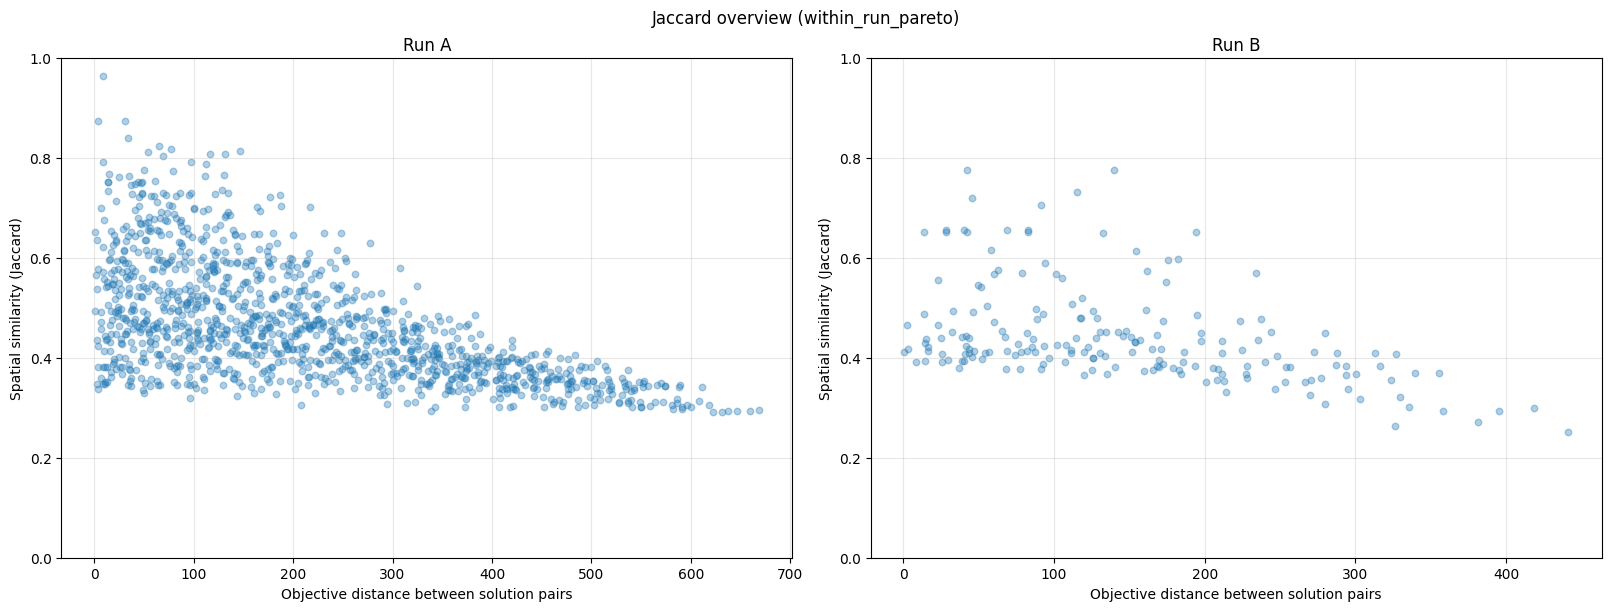


Jaccard overview stats (Run A)
Points used: 1225
Objective distance (min / Q1 / median / Q3 / max): 0.260 / 86.090 / 184.281 / 325.596 / 668.509
Jaccard similarity (min / Q1 / median / Q3 / max): 0.292 / 0.378 / 0.441 / 0.534 / 0.964
Pearson correlation (distance vs similarity):  -0.592
Spearman correlation (distance vs similarity): -0.605

Jaccard overview stats (Run B)
Points used: 190
Objective distance (min / Q1 / median / Q3 / max): 0.447 / 63.585 / 128.447 / 210.638 / 441.319
Jaccard similarity (min / Q1 / median / Q3 / max): 0.252 / 0.384 / 0.415 / 0.475 / 0.776
Pearson correlation (distance vs similarity):  -0.464
Spearman correlation (distance vs similarity): -0.498


In [19]:
if len(jaccard_outputs) > 0:
    plot_items = []

    for out in jaccard_outputs:
        if JACCARD_MODE == "within_run_pareto" and out["pair_df"] is not None and len(out["pair_df"]) > 0:
            plot_df = out["pair_df"][["objective_distance", "jaccard_similarity"]].dropna().copy()
            x_col = "objective_distance"
            y_col = "jaccard_similarity"
            x_label = "Objective distance between solution pairs"
            y_label = "Spatial similarity (Jaccard)"
            title = out["label"]
        else:
            if "mean_obj_distance" not in out["summary_df"].columns or "mean_jaccard" not in out["summary_df"].columns:
                continue
            plot_df = out["summary_df"][["mean_obj_distance", "mean_jaccard"]].dropna().copy()
            x_col = "mean_obj_distance"
            y_col = "mean_jaccard"
            x_label = "Mean objective distance"
            y_label = "Mean spatial similarity (Jaccard)"
            title = out["label"]

        if len(plot_df) == 0:
            continue

        plot_items.append({
            "label": out["label"],
            "plot_df": plot_df,
            "x_col": x_col,
            "y_col": y_col,
            "x_label": x_label,
            "y_label": y_label,
            "title": title,
        })

    if len(plot_items) == 0:
        print("No valid objective-distance/Jaccard pairs to plot.")
    else:
        n_cols = len(plot_items)
        fig, axes = plt.subplots(1, n_cols, figsize=(8 * n_cols, 6), constrained_layout=True)
        if n_cols == 1:
            axes = [axes]

        for ax, item in zip(axes, plot_items):
            plot_df = item["plot_df"]
            ax.scatter(plot_df[item["x_col"]], plot_df[item["y_col"]], alpha=0.35, s=22, color="tab:blue")
            ax.set_xlabel(item["x_label"])
            ax.set_ylabel(item["y_label"])
            ax.set_title(item["title"])
            ax.set_ylim(0, 1)
            ax.grid(True, alpha=0.3)

        fig.suptitle(f"Jaccard overview ({JACCARD_MODE})")
        plt.show()

        for item in plot_items:
            plot_df = item["plot_df"]
            n = len(plot_df)
            x_stats = plot_df[item["x_col"]].describe(percentiles=[0.25, 0.5, 0.75])
            y_stats = plot_df[item["y_col"]].describe(percentiles=[0.25, 0.5, 0.75])
            pearson_r = plot_df[item["x_col"]].corr(plot_df[item["y_col"]], method="pearson")
            spearman_r = plot_df[item["x_col"]].corr(plot_df[item["y_col"]], method="spearman")

            print(f"\nJaccard overview stats ({item['label']})")
            print(f"Points used: {n}")
            print(
                f"Objective distance (min / Q1 / median / Q3 / max): "
                f"{x_stats['min']:.3f} / {x_stats['25%']:.3f} / {x_stats['50%']:.3f} / {x_stats['75%']:.3f} / {x_stats['max']:.3f}"
            )
            print(
                f"Jaccard similarity (min / Q1 / median / Q3 / max): "
                f"{y_stats['min']:.3f} / {y_stats['25%']:.3f} / {y_stats['50%']:.3f} / {y_stats['75%']:.3f} / {y_stats['max']:.3f}"
            )
            print(f"Pearson correlation (distance vs similarity):  {pearson_r:.3f}")
            print(f"Spearman correlation (distance vs similarity): {spearman_r:.3f}")
else:
    print("No Jaccard analysis results available.")

## Pareto front comparison

Parallelization enabled with 24 processes
Plotting Pareto front: 50 solutions, 3 objectives
✓ Pareto front plot saved to: notebook_outputs\pareto_front_forest_run_a.png
Saved Pareto front figure (Run A) to: notebook_outputs\pareto_front_forest_run_a.png
Parallelization enabled with 24 processes
Plotting Pareto front: 20 solutions, 3 objectives
✓ Pareto front plot saved to: notebook_outputs\pareto_front_forest_run_b.png
Saved Pareto front figure (Run B) to: notebook_outputs\pareto_front_forest_run_b.png


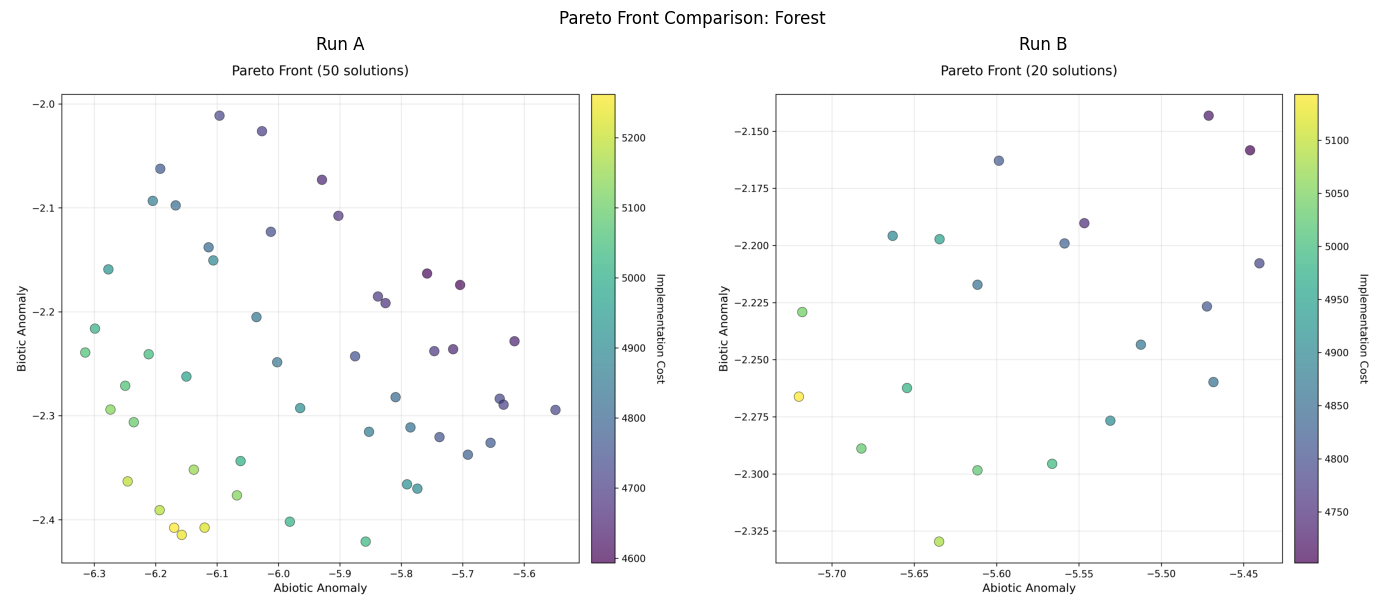

In [20]:
from contextlib import contextmanager

@contextmanager
def _suppress_matplotlib_show():
    original_show = plt.show
    try:
        plt.show = lambda *args, **kwargs: None
        yield
    finally:
        plt.show = original_show

pareto_outputs = []
pareto_paths = []

for run in loaded_runs:
    safe_label = run["label"].lower().replace(" ", "_")
    pareto_path = OUTPUT_DIR / f"pareto_front_{ECOSYSTEM}_{safe_label}.png"

    with _suppress_matplotlib_show():
        pareto_fig = plot_pareto_front(
            pkl_path=str(run["plot_path"]),
            save_path=str(pareto_path),
            figsize=(10, 8),
            alpha=0.7,
        )
    plt.close(pareto_fig)

    pareto_paths.append(pareto_path)
    pareto_outputs.append({
        "label": run["label"],
        "path": pareto_path,
    })
    print(f"Saved Pareto front figure ({run['label']}) to: {pareto_path}")

if len(pareto_outputs) > 0:
    n_cols = len(pareto_outputs)
    fig, axes = plt.subplots(1, n_cols, figsize=(7 * n_cols, 6), constrained_layout=True)
    if n_cols == 1:
        axes = [axes]

    for ax, out in zip(axes, pareto_outputs):
        img = plt.imread(out["path"])
        ax.imshow(img)
        ax.set_title(out["label"])
        ax.axis("off")

    fig.suptitle(f"Pareto Front Comparison: {ECOSYSTEM.title()}")
    plt.show()

## Parallel coordinates comparison

Parallelization enabled with 24 processes
Plotting parallel coordinates: 50 solutions, 3 objectives
✓ Parallel coordinates plot saved to: notebook_outputs\parallel_coordinates_forest_run_a.png
Saved parallel coordinates figure (Run A) to: notebook_outputs\parallel_coordinates_forest_run_a.png
Parallelization enabled with 24 processes
Plotting parallel coordinates: 20 solutions, 3 objectives
✓ Parallel coordinates plot saved to: notebook_outputs\parallel_coordinates_forest_run_b.png
Saved parallel coordinates figure (Run B) to: notebook_outputs\parallel_coordinates_forest_run_b.png


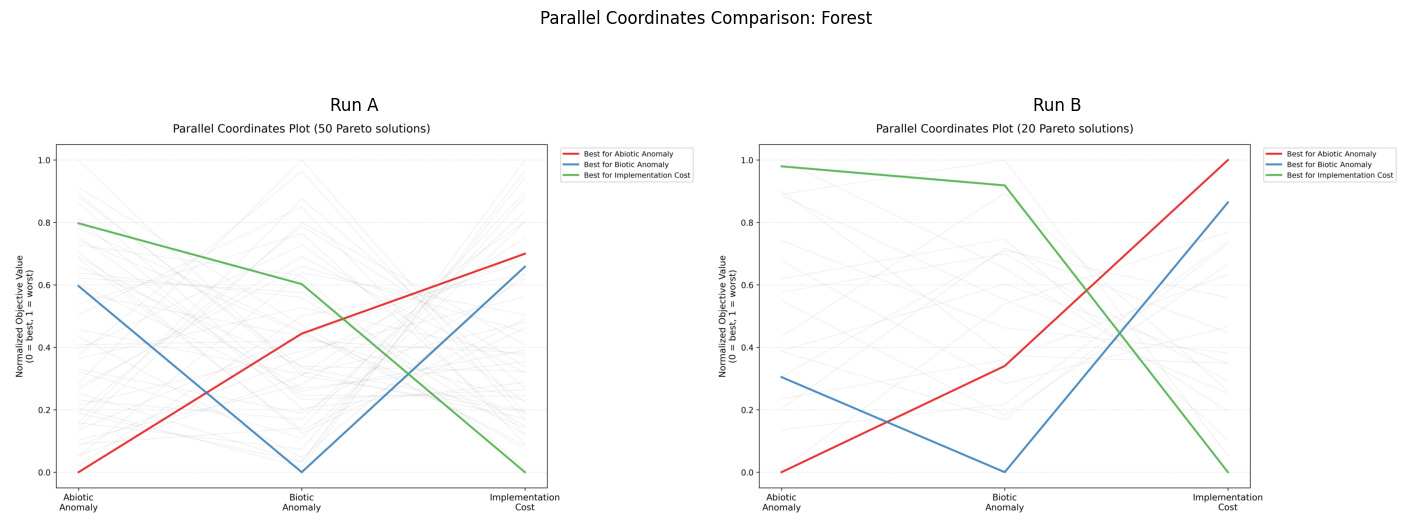

In [21]:
from contextlib import contextmanager

@contextmanager
def _suppress_matplotlib_show():
    original_show = plt.show
    try:
        plt.show = lambda *args, **kwargs: None
        yield
    finally:
        plt.show = original_show

parallel_outputs = []
parallel_paths = []

for run in loaded_runs:
    safe_label = run["label"].lower().replace(" ", "_")
    parallel_path = OUTPUT_DIR / f"parallel_coordinates_{ECOSYSTEM}_{safe_label}.png"

    with _suppress_matplotlib_show():
        parallel_fig = plot_parallel_coordinates(
            pkl_path=str(run["plot_path"]),
            save_path=str(parallel_path),
            figsize=(12, 7),
            alpha_background=0.15,
        )
    plt.close(parallel_fig)

    parallel_paths.append(parallel_path)
    parallel_outputs.append({
        "label": run["label"],
        "path": parallel_path,
    })
    print(f"Saved parallel coordinates figure ({run['label']}) to: {parallel_path}")

if len(parallel_outputs) > 0:
    n_cols = len(parallel_outputs)
    fig, axes = plt.subplots(1, n_cols, figsize=(7 * n_cols, 6), constrained_layout=True)
    if n_cols == 1:
        axes = [axes]

    for ax, out in zip(axes, parallel_outputs):
        img = plt.imread(out["path"])
        ax.imshow(img)
        ax.set_title(out["label"])
        ax.axis("off")

    fig.suptitle(f"Parallel Coordinates Comparison: {ECOSYSTEM.title()}")
    plt.show()

## Optional summary

Run this cell if you want a quick confirmation of the generated outputs.

In [22]:
output_files = []
output_files.extend(selection_paths if "selection_paths" in locals() else [])

if "agreement_csv_paths" in locals() and len(agreement_csv_paths) > 0:
    output_files.extend(agreement_csv_paths)
elif agreement_csv is not None:
    output_files.append(agreement_csv)

if "jaccard_pair_csv_paths" in locals() and len(jaccard_pair_csv_paths) > 0:
    output_files.extend(jaccard_pair_csv_paths)
elif jaccard_pair_csv is not None:
    output_files.append(jaccard_pair_csv)

if "jaccard_matrix_csv_paths" in locals() and len(jaccard_matrix_csv_paths) > 0:
    output_files.extend(jaccard_matrix_csv_paths)
elif jaccard_matrix_csv is not None:
    output_files.append(jaccard_matrix_csv)

output_files.extend(pareto_paths if "pareto_paths" in locals() else [])
output_files.extend(parallel_paths if "parallel_paths" in locals() else [])

for path in output_files:
    print(f"{Path(path).name}: {'found' if Path(path).exists() else 'missing'}")

selection_frequency_forest_run_a.png: found
selection_frequency_forest_run_b.png: found
jaccard_within_run_forest_run_a_pareto_summary.csv: found
jaccard_within_run_forest_run_b_pareto_summary.csv: found
jaccard_within_run_forest_run_a_pareto_pairs.csv: found
jaccard_within_run_forest_run_b_pareto_pairs.csv: found
jaccard_within_run_forest_run_a_pareto_matrix.csv: found
jaccard_within_run_forest_run_b_pareto_matrix.csv: found
pareto_front_forest_run_a.png: found
pareto_front_forest_run_b.png: found
parallel_coordinates_forest_run_a.png: found
parallel_coordinates_forest_run_b.png: found
